In [1]:
def test(model, test_loader):
    model.eval()
    test_total = 0
    test_correct = 0
    # Disable gradient calculation for faster inference
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long()
            # Forward pass
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            # Update correct and total counts
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()
    # Calculate accuracy
    test_accuracy = 100 * test_correct / test_total
    print(f'Test Accuracy: {test_accuracy:.2f}%')
    return test_accuracy

In [6]:
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import os

os.chdir("/home/bobsun/cambrige/MedMinist")
os.system("pwd")

BATCH_SIZE = 512

dataset_name = "pathmnist"
num_classes = 9

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
from medmnist.dataset import PathMNIST

# load the data
test_dataset = PathMNIST(split='val', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                         download=True)

# encapsulate data into dataloader form
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
den_finetune = torch.load('path_DEN_V6_94.33.pth', map_location=device)
resnet = torch.load('path_resnet.pth', map_location='cpu').to(device)
resnet34 = torch.load('path_resnet34.pth', map_location='cpu').to(device)

/home/bobsun/cambrige/MedMinist
Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/pathmnist_224.npz


In [7]:
import torch
import numpy as np
import torch.utils.data as data
import torchvision.transforms as transforms

BATCH_SIZE = 512

dataset_name = "bloodmnist"
num_classes = 8

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
from medmnist.dataset import BloodMNIST

# load the data
test_dataset = BloodMNIST(split='val', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                         download=True)

# encapsulate data into dataloader form
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
den_finetune = torch.load('blood_DEN.pth', map_location=device)
resnet = torch.load('blood_resnet.pth', map_location='cpu').to(device)
resnet34 = torch.load('blood_resnet34.pth', map_location='cpu').to(device)
test(den_finetune, test_loader)
test(resnet, test_loader)
test(resnet34, test_loader)

Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/bloodmnist_224.npz
Test Accuracy: 96.50%
Test Accuracy: 98.25%
Test Accuracy: 96.90%


96.90420560747664

In [10]:
# 初始化存储列表
drops_DEN_soft, drops_DEN_hard, ead_DEN = [], [], []
drops_Grad_soft, drops_Grad_hard, ead_Grad = [], [], []
drops_LayerCAM_soft, drops_LayerCAM_hard, ead_LayerCAM = [], [], []

count = 0

# 定义面积权重函数 f(x)
def area_weight(x, a=5, k=256, n=2.5):
    """
    面积权重函数 f(x)
    :param x: 面积比例 (0 <= x <= 1)
    :param a: 权重函数的最大值
    :param k: 控制衰减速率的参数
    :param n: 控制衰减形状的参数
    :return: 权重 f(x)
    """
    return a * (x / (1 + k * x**(2 * n)))

# 遍历整个 test_loader
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    for idx in range(images.size(0)):  # 遍历每个样本
        count += 1
        if count % 20 == 0:
            print(f"Processed {count} samples...")
        
        img_tensor = images[idx].unsqueeze(0)  # 单个样本
        label = labels[idx]

        # 生成 DEN 显著性图
        activation_map_DEN = extract_all_cam(den_finetune, img_tensor, label,
                                             non_negative=1,
                                             negative=-1,
                                             sharpness=1 / num_classes + 0.1,
                                             sharpness_n=0 / num_classes + 0.1,
                                             activation="activation_all",
                                             alpha=0.9)

        # 生成 Grad-CAM 显著性图
        activation_map_grad = generate_grad_cam_image_single(resnet, img_tensor)

        # 生成 LayerCAM 显著性图
        activation_map_layer = generate_layer_cam_image(resnet, img_tensor)

        # 获取原始置信度（使用 resnet34 计算）
        with torch.no_grad():
            outputs_orig = resnet34(img_tensor)
            p_orig = torch.softmax(outputs_orig, dim=1)[0, label].item()


        # 处理显著性图 (DEN, Grad-CAM, LayerCAM)
        for activation_map, drops_soft, drops_hard, ead_list, map_name in [
            (activation_map_DEN, drops_DEN_soft, drops_DEN_hard, ead_DEN, "DEN"),
            (activation_map_grad, drops_Grad_soft, drops_Grad_hard, ead_Grad, "Grad-CAM"),
            (activation_map_layer, drops_LayerCAM_soft, drops_LayerCAM_hard, ead_LayerCAM, "LayerCAM"),
        ]:
            # 转换显著性图为 Tensor
            activation_map = torch.from_numpy(activation_map).float().to(device)
            weight = activation_map.unsqueeze(0).unsqueeze(0)  # CAM 强度作为权重
            
            
            # 图像均值
            img_mean = img_tensor.mean(dim=(2, 3), keepdim=True)
            # Soft 替换：根据显著性强度填充均值
            img_soft_masked = img_tensor.clone()
            img_soft_masked = img_soft_masked * (1 - weight) + img_mean * weight
            with torch.no_grad():
                outputs_soft = resnet34(img_soft_masked)
                p_soft_masked = torch.softmax(outputs_soft, dim=1)[0, label].item()
            drop_soft = max(0, (p_orig - p_soft_masked) / p_orig)
            drops_soft.append(drop_soft)

            # Hard 替换：超过阈值的显著性区域直接置零
            img_hard_masked = img_tensor.clone()
            threshold_mask = (activation_map > 0.5).float()  # 假设阈值为 0.5
            img_hard_masked = img_hard_masked * (1 - threshold_mask)
            with torch.no_grad():
                outputs_hard = resnet34(img_hard_masked)
                p_hard_masked = torch.softmax(outputs_hard, dim=1)[0, label].item()
            drop_hard = max(0, (p_orig - p_hard_masked) / p_orig)
            drops_hard.append(drop_hard)

            # 计算面积比例
            cam_area = (activation_map > 0.2).float().mean().item()

            # 计算 Effective Drop
            effective_weight = area_weight(cam_area)  # f(x)
            ead = drop_hard * effective_weight
            ead_list.append(ead)

    # 测试阶段，为加快运行可加上 break（实际训练时请移除）
    break

# 计算所有方法的指标
def calculate_avg(drops):
    return sum(drops) / len(drops) if drops else 0

avg_drop_DEN_soft = calculate_avg(drops_DEN_soft)
avg_drop_DEN_hard = calculate_avg(drops_DEN_hard)
avg_ead_DEN = calculate_avg(ead_DEN)

avg_drop_Grad_soft = calculate_avg(drops_Grad_soft)
avg_drop_Grad_hard = calculate_avg(drops_Grad_hard)
avg_ead_Grad = calculate_avg(ead_Grad)

avg_drop_LayerCAM_soft = calculate_avg(drops_LayerCAM_soft)
avg_drop_LayerCAM_hard = calculate_avg(drops_LayerCAM_hard)
avg_ead_LayerCAM = calculate_avg(ead_LayerCAM)

print(f"Average Drop (Soft) for DEN: {avg_drop_DEN_soft:.4f}")
print(f"Average Drop (Soft) for Grad-CAM: {avg_drop_Grad_soft:.4f}")
print(f"Average Drop (Soft) for LayerCAM: {avg_drop_LayerCAM_soft:.4f}")

print(f"Average Drop (Hard) for DEN: {avg_drop_DEN_hard:.4f}")
print(f"Average Drop (Hard) for Grad-CAM: {avg_drop_Grad_hard:.4f}")
print(f"Average Drop (Hard) for LayerCAM: {avg_drop_LayerCAM_hard:.4f}")
print(f"Effective AVG Drop (EAD) for DEN: {avg_ead_DEN:.4f}")
print(f"Effective AVG Drop (EAD) for Grad-CAM: {avg_ead_Grad:.4f}")
print(f"Effective AVG Drop (EAD) for LayerCAM: {avg_ead_LayerCAM:.4f}")

Processed 20 samples...
Processed 40 samples...
Processed 60 samples...
Processed 80 samples...
Processed 100 samples...
Processed 120 samples...
Processed 140 samples...
Processed 160 samples...
Processed 180 samples...
Processed 200 samples...
Processed 220 samples...
Processed 240 samples...
Processed 260 samples...
Processed 280 samples...
Processed 300 samples...
Processed 320 samples...
Processed 340 samples...
Processed 360 samples...
Processed 380 samples...
Processed 400 samples...
Processed 420 samples...
Processed 440 samples...
Processed 460 samples...
Processed 480 samples...
Processed 500 samples...
Average Drop (Soft) for DEN: 0.5007
Average Drop (Soft) for Grad-CAM: 0.4993
Average Drop (Soft) for LayerCAM: 0.5078
Average Drop (Hard) for DEN: 0.7212
Average Drop (Hard) for Grad-CAM: 0.7765
Average Drop (Hard) for LayerCAM: 0.7837
Effective AVG Drop (EAD) for DEN: 0.1894
Effective AVG Drop (EAD) for Grad-CAM: 0.1106
Effective AVG Drop (EAD) for LayerCAM: 0.0808


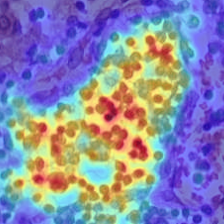

In [33]:
#单张解释
from torchcam.utils import overlay_mask
from PIL import Image

# path: 14 19 24 26 29 30 33 41 43!! 48 49!! 54 57 62 76
idx = 62
images, labels = next(iter(test_loader))
img_tensor = images[idx].unsqueeze(0).to(device)

label = labels[idx]
activation_map_DEN = extract_all_cam(den_finetune, img_tensor, label,
                                     non_negative=1,
                                     negative=-1,
                                     sharpness=1 / num_classes + 0.1,
                                     sharpness_n=0 / num_classes + 0.1,
                                     activation="activation_all",
                                     alpha=0.9)

img = img_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
img = (img * 0.5 + 0.5) * 255
img = img.astype(np.uint8)

overlay_image = overlay_mask(Image.fromarray(img), Image.fromarray(activation_map_DEN, mode='F'), alpha=0.5)
overlay_image

In [35]:
activation_map_grad.shape

(7, 7)

True Class: normal colon mucosa


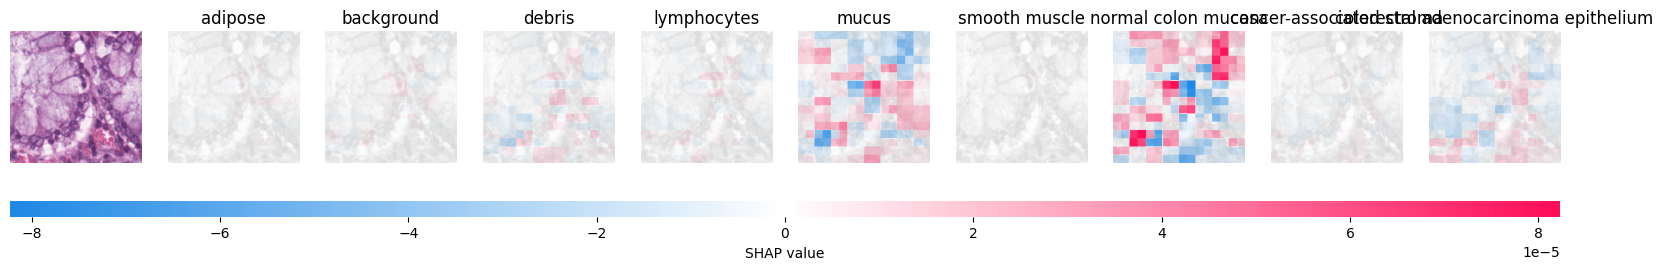

In [19]:
shap_values, class_name = generate_shap_explanation(resnet, test_loader, idx, max_evals=5000, batch_size=256,class_name=dataset_name,masker_type="blur(8,8)")

6

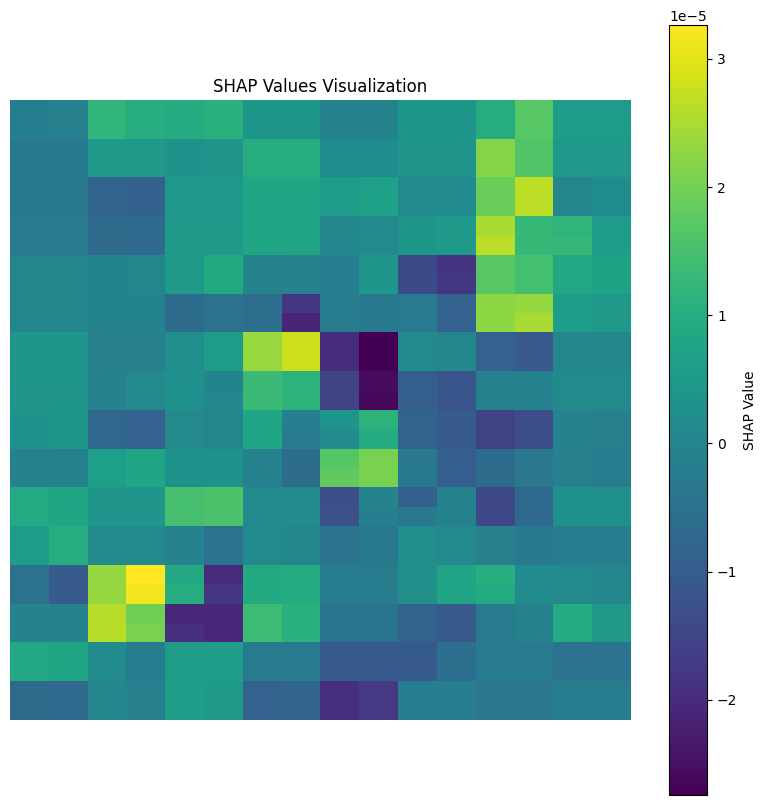

In [31]:
shap_values.data.shape
# print(dir(shap_values))
shap_values.data
import matplotlib.pyplot as plt

shap_value_sample = shap_values.values[0, :, :, 0, label.item()]

plt.figure(figsize=(10, 10))
plt.imshow(shap_value_sample, interpolation='nearest')
plt.title("SHAP Values Visualization")
plt.colorbar(label="SHAP Value")
plt.axis('off')
plt.show()

In [35]:
activation_map_grad = generate_grad_cam_image_single(resnet, img_tensor)


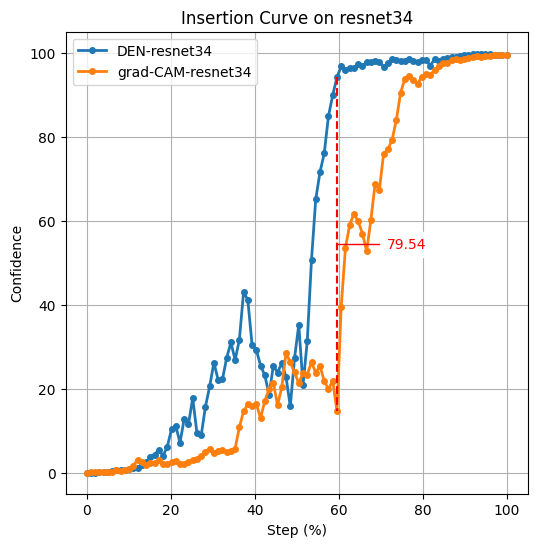

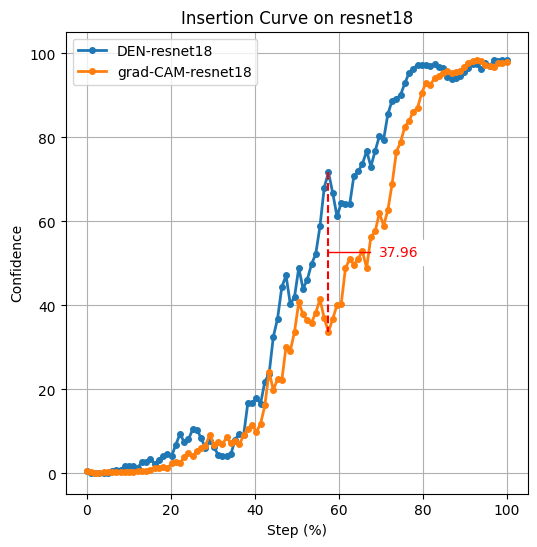

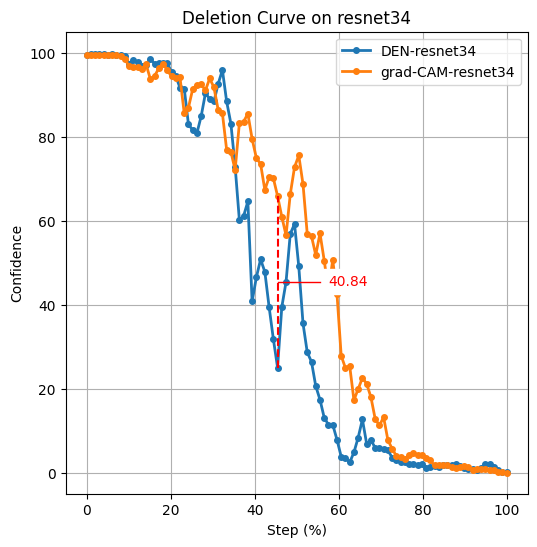

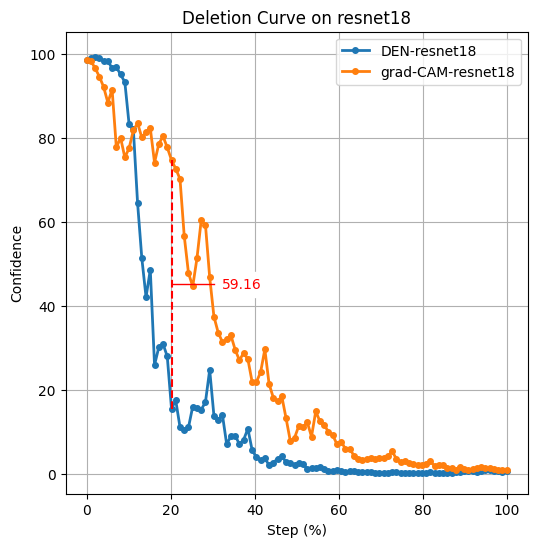

In [36]:
DEN34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_DEN,
                                   metric="insertion")  # deletion insertion
grad18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_grad,
                                    metric="insertion")  # deletion insertion
grad34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_grad,
                                    metric="insertion")  # deletion insertion
DEN18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_DEN,
                                   metric="insertion")  # deletion insertion

a = plot_multiple_curves_with_max_diff([DEN34 * 100, grad34 * 100],
                                       ["DEN-resnet34", "grad-CAM-resnet34"],
                                       ["-", "-"],
                                       title="Insertion Curve on resnet34")
b = plot_multiple_curves_with_max_diff([DEN18 * 100, grad18 * 100],
                                       ["DEN-resnet18", "grad-CAM-resnet18"],
                                       ["-", "-"],
                                       title="Insertion Curve on resnet18")

DEN34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_DEN,
                                   metric="deletion")  # deletion insertion
grad18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_grad,
                                    metric="deletion")  # deletion insertion
grad34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_grad,
                                    metric="deletion")  # deletion insertion
DEN18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_DEN,
                                   metric="deletion")  # deletion insertion
c = plot_multiple_curves_with_max_diff([DEN34 * 100, grad34 * 100],
                                       ["DEN-resnet34", "grad-CAM-resnet34"],
                                       ["-", "-"],
                                       title="Deletion Curve on resnet34")
d = plot_multiple_curves_with_max_diff([DEN18 * 100, grad18 * 100],
                                       ["DEN-resnet18", "grad-CAM-resnet18"],
                                       ["-", "-"],
                                       title="Deletion Curve on resnet18")


In [2]:
# Insertion/Deletion Curve for DEN
for img, tgt in test_loader:
    curve_list = []
    for i in range(BATCH_SIZE):
        img_tensor = img[i].unsqueeze(0).to(device)
        label = tgt[i]
        activation_map = extract_all_cam(den_finetune, img_tensor, label,
                                         non_negative=1,
                                         negative=-1,
                                         sharpness=1 / num_classes + 0.1,
                                         sharpness_n=0 / num_classes + 0.1,
                                         activation="activation_all",
                                         alpha=0.9)
        curve = evaluate_CAM_single_sample(den_finetune, img_tensor, label, activation_map)
        curve_list.append(curve)
    break

NameError: name 'extract_all_cam' is not defined

In [38]:
for img, tgt in test_loader:
    curve_list = []
    for i in range(BATCH_SIZE):
        img_tensor = img[i].unsqueeze(0).to(device)
        label = tgt[i]
        result, activation_map = generate_grad_cam_image_single(resnet, img_tensor)
        curve = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map)
        curve_list.append(curve)
    break

KeyboardInterrupt: 

In [183]:


# 定义曲线存储
DEN_insertion_resnet34 = []
DEN_insertion_resnet18 = []
Grad_insertion_resnet34 = []
Grad_insertion_resnet18 = []

DEN_deletion_resnet34 = []
DEN_deletion_resnet18 = []
Grad_deletion_resnet34 = []
Grad_deletion_resnet18 = []

# 遍历数据集
for img, tgt in test_loader:
    for i in range(img.size(0)):  # 遍历每个批次中的样本
        img_tensor = img[i].unsqueeze(0).to(device)
        label = tgt[i].to(device)

        # 计算 DEN 插入曲线
        activation_map_DEN = extract_all_cam(
            den_finetune, img_tensor, label,
            non_negative=1,
            negative=-1,
            sharpness=1 / num_classes + 0.1,
            sharpness_n=0 / num_classes + 0.1,
            activation="activation_all",
            alpha=0.9
        )
        curve_insertion_DEN_resnet34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_DEN,
                                                                  metric="insertion")
        DEN_insertion_resnet34.append(curve_insertion_DEN_resnet34)

        curve_deletion_DEN_resnet34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_DEN,
                                                                 metric="deletion")
        DEN_deletion_resnet34.append(curve_deletion_DEN_resnet34)

        curve_insertion_DEN_resnet18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_DEN,
                                                                  metric="insertion")
        DEN_insertion_resnet18.append(curve_insertion_DEN_resnet18)

        curve_deletion_DEN_resnet18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_DEN,
                                                                 metric="deletion")
        DEN_deletion_resnet18.append(curve_deletion_DEN_resnet18)

        # 计算 Grad-CAM 插入曲线
        result, activation_map_grad = generate_grad_cam_image_single(resnet, img_tensor)
        curve_insertion_Grad_resnet34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_grad,
                                                                   metric="insertion")
        Grad_insertion_resnet34.append(curve_insertion_Grad_resnet34)

        curve_deletion_Grad_resnet34 = evaluate_CAM_single_sample(resnet34, img_tensor, label, activation_map_grad,
                                                                  metric="deletion")
        Grad_deletion_resnet34.append(curve_deletion_Grad_resnet34)

        curve_insertion_Grad_resnet18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_grad,
                                                                   metric="insertion")
        Grad_insertion_resnet18.append(curve_insertion_Grad_resnet18)

        curve_deletion_Grad_resnet18 = evaluate_CAM_single_sample(resnet, img_tensor, label, activation_map_grad,
                                                                  metric="deletion")
        Grad_deletion_resnet18.append(curve_deletion_Grad_resnet18)
    break

# # 转为 NumPy 数组并计算平均值
# DEN_insertion_resnet34 = np.mean(DEN_insertion_resnet34, axis=0)
# DEN_insertion_resnet18 = np.mean(DEN_insertion_resnet18, axis=0)
# Grad_insertion_resnet34 = np.mean(Grad_insertion_resnet34, axis=0)
# Grad_insertion_resnet18 = np.mean(Grad_insertion_resnet18, axis=0)
# 
# DEN_deletion_resnet34 = np.mean(DEN_deletion_resnet34, axis=0)
# DEN_deletion_resnet18 = np.mean(DEN_deletion_resnet18, axis=0)
# Grad_deletion_resnet34 = np.mean(Grad_deletion_resnet34, axis=0)
# Grad_deletion_resnet18 = np.mean(Grad_deletion_resnet18, axis=0)
# 
# plot_multiple_curves_with_max_diff([DEN_insertion_resnet18 * 100, Grad_insertion_resnet18 * 100],
#                          ["DEN-resnet18", "grad-CAM-resnet18"],
#                          ["-", "-"],
#                          title="Average Insertion Curve on resnet18")
# plot_multiple_curves_with_max_diff([DEN_insertion_resnet34 * 100, Grad_insertion_resnet34 * 100],
#                          ["DEN-resnet34", "grad-CAM-resnet34"],
#                          ["-", "-"],
#                          title="Average Insertion Curve on resnet34")
# plot_multiple_curves_with_max_diff([DEN_deletion_resnet18 * 100, Grad_deletion_resnet18 * 100],
#                          ["DEN-resnet18", "grad-CAM-resnet18"],
#                          ["-", "-"],
#                          title="Average Deletion Curve on resnet18")
# plot_multiple_curves_with_max_diff([DEN_deletion_resnet34 * 100, Grad_deletion_resnet34 * 100],
#                          ["DEN-resnet18", "grad-CAM-resnet18"],
#                          ["-", "-"],
#                          title="Average Deletion Curve on resnet34")

Traceback (most recent call last):
  File "/home/bobsun/miniconda3/envs/bob/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/bobsun/miniconda3/envs/bob/lib/python3.8/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/bobsun/miniconda3/envs/bob/lib/python3.8/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/bobsun/miniconda3/envs/bob/lib/python3.8/shutil.py", line 722, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/bobsun/miniconda3/envs/bob/lib/python3.8/shutil.py", line 720, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-old1txbp'
Traceback (most recent call last):
  File "/home/bobsun/miniconda3/envs/bob/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/bobsun/miniconda3/envs/bob/lib/python3.8/multiprocessing/util.py", line 224, 

In [5]:



# 定义 AUC 计算函数
def calculate_auc(curves):
    """
    计算每条曲线的 AUC。
    :param curves: List[np.ndarray]，每个样本的曲线数组。
    :return: List[float]，每个样本的 AUC 值。
    """
    aucs = []
    for curve in curves:
        step_size = 1 / len(curve)  # 假设曲线点均匀分布
        auc = step_size * np.sum(curve)
        aucs.append(auc)
    return aucs


# 收集 AUC 数据
DEN_insertion_resnet34_auc = calculate_auc(DEN_insertion_resnet34)
DEN_insertion_resnet18_auc = calculate_auc(DEN_insertion_resnet18)
Grad_insertion_resnet34_auc = calculate_auc(Grad_insertion_resnet34)
Grad_insertion_resnet18_auc = calculate_auc(Grad_insertion_resnet18)

DEN_deletion_resnet34_auc = calculate_auc(DEN_deletion_resnet34)
DEN_deletion_resnet18_auc = calculate_auc(DEN_deletion_resnet18)
Grad_deletion_resnet34_auc = calculate_auc(Grad_deletion_resnet34)
Grad_deletion_resnet18_auc = calculate_auc(Grad_deletion_resnet18)


# 绘制箱形图
def plot_auc_boxplot(auc_data, labels, title="AUC Boxplot"):
    """
    绘制箱形图，显示 AUC 的分布。
    :param auc_data: List[List[float]]，每种曲线的 AUC 数据。
    :param labels: List[str]，每种曲线的标签。
    :param title: str，图的标题。
    """
    plt.figure(figsize=(10, 6))
    plt.boxplot(auc_data, labels=labels, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    plt.title(title)
    plt.ylabel("AUC")
    plt.grid(axis='y')
    plt.xticks(rotation=45)
    plt.show()


# 准备箱形图数据
auc_data = [
    DEN_insertion_resnet34_auc,
    Grad_insertion_resnet34_auc,

    DEN_insertion_resnet18_auc,
    Grad_insertion_resnet18_auc,

    DEN_deletion_resnet34_auc,
    Grad_deletion_resnet34_auc,

    DEN_deletion_resnet18_auc,
    Grad_deletion_resnet18_auc
]
labels = [
    "DEN-Ins-ResNet34", "Grad-Ins-ResNet34",
    "DEN-Ins-ResNet18", "Grad-Ins-ResNet18",
    "DEN-Del-ResNet34", "Grad-Del-ResNet34",
    "DEN-Del-ResNet18", "Grad-Del-ResNet18",
]

# 绘制箱形图
plot_auc_boxplot(auc_data, labels, title="AUC Boxplot")

NameError: name 'DEN_insertion_resnet34' is not defined

In [20]:
from torchcam.methods import LayerCAM
import cv2
import torch.nn.functional as F
from PIL import ImageDraw, ImageFont

import matplotlib.pyplot as plt


def merge_images(images, grid_size=(2, 2), margin=5, bg_color=(255, 255, 255)):
    # 确定每张图片的统一尺寸（以最小的图片大小为基准缩放）
    min_width = min(img.width for img in images)
    min_height = min(img.height for img in images)
    resized_images = [img.resize((min_width, min_height)) for img in images]

    # 计算输出图片的尺寸
    rows, cols = grid_size
    total_width = cols * min_width + (cols - 1) * margin
    total_height = rows * min_height + (rows - 1) * margin

    # 创建背景画布
    new_image = Image.new("RGB", (total_width, total_height), bg_color)

    # 将图片逐一粘贴到背景画布上
    for idx, img in enumerate(resized_images):
        row, col = divmod(idx, cols)
        x_offset = col * (min_width + margin)
        y_offset = row * (min_height + margin)
        new_image.paste(img, (x_offset, y_offset))

    # 保存拼接后的图片
    new_image.show()


def plot_multiple_curves_with_max_diff(data_list, labels, linestyles, title="Insertion/Deletion Curve",
                                       xlabel="Step (%)", ylabel="Confidence", need_return=True):
    # 参数校验
    if len(data_list) < 2:
        raise ValueError("At least two curves are required for comparison.")
    if not all(isinstance(data, np.ndarray) for data in data_list):
        raise ValueError("All data in data_list must be numpy.ndarray.")
    if not all(data.shape == (100,) for data in data_list):
        raise ValueError("All data in data_list must have shape (100,).")
    if len(data_list) != len(labels):
        raise ValueError("Number of data arrays and labels must match.")
    if len(data_list) != len(linestyles):
        raise ValueError("Number of data arrays and linestyles must match.")

    # X轴表示步长百分比
    x = np.linspace(0, 100, len(data_list[0]))  # 假设所有数据长度一致

    # 绘制多条曲线
    plt.figure(figsize=(6, 6))  # 设置正方形图像
    for data, label, linestyle in zip(data_list, labels, linestyles):
        plt.plot(x, data, marker='o', linestyle=linestyle, markersize=4, linewidth=2, label=label)

    # 计算两条曲线的差距并标注最大差距点（仅比较前两条曲线）
    curve1, curve2 = data_list[0], data_list[1]
    diff = np.abs(curve1 - curve2)
    max_diff_index = np.argmax(diff)
    max_diff_x = x[max_diff_index]
    max_diff_y1 = curve1[max_diff_index]
    max_diff_y2 = curve2[max_diff_index]
    max_diff_value = diff[max_diff_index]

    # 在图中标注差距最大的点
    # 1. 画竖线
    plt.plot([max_diff_x, max_diff_x], [max_diff_y1, max_diff_y2], color='red', linestyle='--', linewidth=1.5)
    # 2. 画水平线，向右引出
    extend_length = 10  # 水平延伸的长度
    line_end_x = max_diff_x + extend_length
    mid_y = (max_diff_y1 + max_diff_y2) / 2
    plt.plot([max_diff_x, line_end_x], [mid_y, mid_y], color='red', linestyle='-', linewidth=1)
    # 3. 在水平线的末端标注差距数值
    plt.text(line_end_x + 2, mid_y, f'{max_diff_value:.2f}',
             color='red', fontsize=10, va='center', ha='left', backgroundcolor='white')

    # 图形装饰
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()  # 添加图例
    plt.axis('square')  # 设置坐标轴区域为正方形
    plt.savefig(f"img/{title}.svg", format="svg")
    plt.show()


def plot_multiple_curves(data_list, labels, linestyles, title="Insertion/Deletion Curve", xlabel="Step (%)",
                         ylabel="Confidence", need_return=True):
    """
    绘制多条插入/删除曲线，确保图像为正方形。
    
    参数：
    - data_list: list[numpy.ndarray]，包含多条曲线数据，每条数据应为形状 (100,)。
    - labels: list[str]，对应每条曲线的图例标签。
    - title: 图标题 (str)，默认为 "Insertion/Deletion Curve"。
    - xlabel: X轴标签 (str)，默认为 "Step (%)"。
    - ylabel: Y轴标签 (str)，默认为 "Confidence"。
    - save_path: 保存路径 (str)，如果提供，图像会保存到该路径。
    """
    # 参数校验
    if not all(isinstance(data, np.ndarray) for data in data_list):
        raise ValueError("All data in data_list must be numpy.ndarray.")

    if not all(data.shape == (100,) for data in data_list):
        raise ValueError("All data in data_list must have shape (100,).")

    if len(data_list) != len(labels):
        raise ValueError("Number of data arrays and labels must match.")

    # X轴表示步长百分比
    x = np.linspace(0, 100, len(data_list[0]))  # 假设所有数据长度一致

    # 绘制多条曲线
    plt.figure(figsize=(6, 6))  # 设置正方形图像，宽高比为 1:1
    for data, label, linestyle in zip(data_list, labels, linestyles):
        plt.plot(x, data, marker='o', linestyle=linestyle, markersize=4, linewidth=2, label=label)

    # 图形装饰
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()  # 添加图例
    plt.axis('square')  # 设置坐标轴区域为正方形

    # 保存或显示
    plt.show()

def resize_cam(cam_map, target_shape):
    """调整显著性图到目标大小"""
    cam_map = cam_map.unsqueeze(0)
    
    cam_resized = torch.nn.functional.interpolate(
        cam_map,
        size=target_shape,
        mode='bilinear',
        align_corners=False
    ).squeeze().cpu()  # 返回 numpy 格式
    return cam_resized


def generate_layer_cam_image(model, img_tensor, target_layer='layer4'):
    # 将模型设置为评估模式并加载到设备
    model.to(device)
    model.eval()
    cam_extractor = LayerCAM(model, target_layer=target_layer)
    
    output = model(img_tensor.to(device))

    # 获取预测的类别索引和名称
    predicted_class_idx = output.argmax(dim=1).item()

    # 生成指定类别的 CAM 热力图
    activation_map = cam_extractor(predicted_class_idx, output)

    activation_map = resize_cam(activation_map[0].cpu().detach(),(224,224))
    activation_map = activation_map.squeeze().squeeze().numpy()

    return  activation_map

def generate_grad_cam_image_single(model, img_tensor, target_layer='layer4'):
    # 将模型设置为评估模式并加载到设备
    # model.eval()
    model.to(device)
    # 从 test_loader 中获取一批图像
    images, labels = next(iter(test_loader))
    cam_extractor = GradCAM(model, target_layer=target_layer)
    # 获取指定索引的图像并转移到设备
    output = model(img_tensor.to(device))
    # 如果是单通道图像，转换为三通道

    # 获取预测的类别索引和名称
    predicted_class_idx = output.argmax(dim=1).item()

    # 生成指定类别的 CAM 热力图
    activation_map = cam_extractor(predicted_class_idx, output)

    activation_map = resize_cam(activation_map[0].cpu().detach(),(224,224))
    activation_map = activation_map.squeeze().squeeze().numpy()

    return activation_map


def plot_curve(data, title="Insertion/Deletion Curve", xlabel="Step (%)", ylabel="Confidence", save_path=None):
    # 确保数据为 numpy.ndarray 类型
    if not isinstance(data, np.ndarray):
        raise ValueError("Input data must be a numpy.ndarray.")

    if data.shape != (100,):
        raise ValueError("Input data must have shape (100,).")

    # X轴表示步长百分比
    x = np.linspace(0, 100, len(data))  # 将 0 到 100 均分为 100 个点

    # 绘制曲线
    plt.figure(figsize=(8, 6))
    plt.plot(x, data, marker='o', linestyle='-', markersize=4, linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()


def extract_all_cam(model, img_tensor, label, non_negative=1, negative=0, sharpness=0, sharpness_n=0,
                    activation="activation", alpha=1):
    output = model(img_tensor)
    original_image = img_tensor.cpu().squeeze().numpy()
    if original_image.ndim == 2:  # 单通道 (H, W)
        display_image = (original_image * 0.5 + 0.5) * 255  # 转换到 [0, 255]
        input_image = np.stack([display_image] * 3, axis=-1)  # 转为三通道
    elif original_image.ndim == 3:  # 多通道 (C, H, W)
        input_image = (original_image.transpose(1, 2, 0) * 0.5 + 0.5) * 255

    input_image = input_image.astype('uint8')

    cam_list = []
    for i in range(1, 5):  # 遍历网络的不同层
        for j in range(2):  # 遍历层的分支
            pred_fc = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'pred_fc').weight
            W = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'W').weight
            weight = pred_fc @ W
            feature_map = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), activation)
            logit = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'deep_pred')
            probabilities = F.softmax(logit, dim=1).cpu().detach().numpy()[0]
            predicted_class_idx = np.argmax(probabilities)
            _, activation_map = generate_cam_with_overlay(weight, feature_map, label, input_image,
                                                          non_negative, negative, sharpness, sharpness_n)
            cam_list.append(activation_map)

    # 按权重调整各层的CAM并计算全局CAM
    for i in range(len(cam_list)):
        cam_list[i] = cam_list[i] * (alpha ** (len(cam_list) - (i + 1)))

    all_cam = np.sum(cam_list, axis=0)
    all_cam = (all_cam - all_cam.min()) / (all_cam.max() - all_cam.min())  # 归一化处理

    return all_cam


def evaluate_CAM_single_sample(model, image, label, cam_map, metric='insertion', step=0.01):
    """
    评估单个样本的插入/删除曲线。
    - 未插入或删除的区域将填充为图像的通道均值。
    """
    # 确保模型处于评估模式
    model.eval()
    device = next(model.parameters()).device

    # 将输入图像和标签移动到设备
    image = image.to(device)
    label = label.to(device)

    # 获取输入图像的大小
    _, channels, height, width = image.shape

    # 检查并调整显著性图的大小
    def resize_cam(cam_map, target_shape):
        """调整显著性图到目标大小"""
        cam_tensor = torch.tensor(cam_map).unsqueeze(0).unsqueeze(0)  # (H, W) -> (1, 1, H, W)
        cam_resized = torch.nn.functional.interpolate(
            cam_tensor,
            size=target_shape,
            mode='bilinear',
            align_corners=False
        ).squeeze().cpu().numpy()  # 返回 numpy 格式
        return cam_resized

    cam_resized = resize_cam(cam_map, target_shape=(height, width))

    # 计算每个通道的均值
    channel_means = image.mean(dim=(2, 3), keepdim=True)  # 计算每个通道的均值，形状为 (1, C, 1, 1)

    # 初始化曲线存储
    scores = []
    steps = int(1 / step)  # 插入/删除操作的总步数

    # 逐步操作
    for i in range(steps):
        modified_image = image.clone()

        if metric == 'insertion':
            # 插入：从全均值图像开始逐步插入像素
            mask = np.zeros_like(cam_resized)
            mask[cam_resized >= np.percentile(cam_resized, 100 - i * step * 100)] = 1
            mask = torch.tensor(mask).to(device).float().unsqueeze(0).unsqueeze(0)  # 扩展维度
            modified_image = channel_means + (image - channel_means) * mask
        elif metric == 'deletion':
            # 删除：从原始图像逐步删除像素
            mask = np.ones_like(cam_resized)
            mask[cam_resized >= np.percentile(cam_resized, 100 - i * step * 100)] = 0
            mask = torch.tensor(mask).to(device).float().unsqueeze(0).unsqueeze(0)  # 扩展维度
            modified_image = channel_means + (image - channel_means) * mask
        else:
            raise ValueError(f"Unsupported metric: {metric}")

        # 计算模型输出

        outputs = model(modified_image)
        target_score = torch.softmax(outputs, dim=1)[:, label].item()

        # 保存当前分数
        scores.append(target_score)

    # 返回曲线
    return np.array(scores)


def add_text_to_image(image, text, position=(10, 10), font_size=40, max_width=None, line_spacing=5, add_text=True):
    if not add_text:
        return image
    draw = ImageDraw.Draw(image)
    try:
        # 尝试加载系统默认字体
        font = ImageFont.truetype("arial", font_size)
    except IOError:
        # 使用默认字体
        font = ImageFont.load_default()

    # 如果没有指定最大宽度，则使用图像宽度
    if max_width is None:
        max_width = image.width - position[0] * 2  # 留出一定边距

    # 拆分文本，逐行添加
    lines = []
    words = text.split()
    current_line = ""
    for word in words:
        # 判断当前行加入下一个词后是否超过最大宽度
        test_line = f"{current_line} {word}".strip()
        left, top, right, bottom = font.getbbox(test_line)
        line_width = right - left
        if line_width <= max_width:
            current_line = test_line
        else:
            # 当前行宽度超限，将当前行加入到行列表并重置
            lines.append(current_line)
            current_line = word

    # 添加最后一行
    if current_line:
        lines.append(current_line)

    # 绘制每一行文本
    x, y = position
    for line in lines:
        draw.text((x, y), line, fill="white", font=font)
        _, _, _, line_height = font.getbbox(line)  # 获取当前行的高度
        y += line_height + line_spacing  # 增加行间距

    return image


def get_weight_with_sharpness(full_weight, y, sharpness, sharpness_n):
    # 确保 full_weight 是 PyTorch 张量
    full_weight_pt = full_weight
    weight_pt = full_weight_pt[y]

    # 转换为 NumPy 数组
    full_weight_np = full_weight_pt
    weight_np = weight_pt

    # 处理负向权重
    full_weight_n = -full_weight_np.copy()
    weight_n = -weight_np.copy()

    # 正向权重处理
    full_weight_np[full_weight_np < 0] = 0
    norm = np.sum(full_weight_np, axis=0)
    weight_np[weight_np < 0] = 0
    alpha = weight_np / (norm + 1e-8)
    weight_np[alpha < sharpness] = 0

    # 负向权重处理
    full_weight_n[full_weight_n < 0] = 0
    norm_n = np.sum(full_weight_n, axis=0)
    weight_n[weight_n < 0] = 0
    alpha_n = weight_n / (norm_n + 1e-8)
    weight_n[alpha_n < sharpness_n] = 0

    # 最终权重
    final_weight = weight_np - weight_n

    return final_weight


def generate_cam_with_overlay(fc_weights, feature_map, class_idx, input_image, non_negative=1.0, negative=0,
                              sharpness=0, sharpness_n=0):
    # print("class_idx:",class_idx)
    weights = fc_weights[class_idx].cpu().detach().numpy()
    if (sharpness > 0 or sharpness_n > 0):
        weights = get_weight_with_sharpness(fc_weights.cpu().detach().numpy(), class_idx, sharpness, sharpness_n)
    B, C, H, W = feature_map.shape
    feature_map = feature_map.cpu().detach().numpy()

    # 计算正向 CAM
    weights_positive = np.clip(weights, a_min=0, a_max=None)
    weights_negative = np.clip(-weights, a_min=0, a_max=None)
    weights_final = non_negative * weights_positive + negative * weights_negative
    cam_positive = np.sum(weights_final[:, None, None] * feature_map[0], axis=0)
    cam_return = cam_positive.copy()

    # 归一化 CAM
    min_val = np.percentile(cam_positive, 1)
    max_val = np.percentile(cam_positive, 99)
    cam_positive = (cam_positive - min_val) / (max_val - min_val)
    cam_positive[cam_positive < 0.1] = 0
    cam_positive[cam_positive > 1.0] = 1.0
    cam_positive_resized = cv2.resize(cam_positive, (input_image.shape[1], input_image.shape[0]))
    cam_return = cv2.resize(cam_return, (input_image.shape[1], input_image.shape[0]))

    # 将激活图转换为 PIL Image 格式
    activation_map = Image.fromarray(cam_positive_resized, mode='F')

    # 使用 overlay_mask 叠加
    overlay_image = overlay_mask(Image.fromarray(input_image), activation_map, alpha=0.5)

    return overlay_image, cam_return


def draw(img_list, input_image=None, cam_list=None, class_names=[], label=0, predicted_class="", confidence=0.0):
    # 累加所有 CAM，并进行归一化处理

    if input_image is not None:
        all_cam = np.sum(cam_list, axis=0)
        all_cam = (all_cam - all_cam.min()) / (all_cam.max() - all_cam.min())

        # 将叠加的 CAM 转换为 PIL Image 格式
        all_cam_img = Image.fromarray(all_cam, mode='F')
        overlay_all_cam = overlay_mask(Image.fromarray(input_image), all_cam_img, alpha=0.5)

        # 在原图上添加实际类别
        original_image_with_text = add_text_to_image(Image.fromarray(input_image), f"True Class: {class_names[label]}")
        # 在全叠加的 CAM 图上添加预测类别和置信度
        overlay_all_cam_with_text = add_text_to_image(overlay_all_cam, f"P: {predicted_class}, C: {confidence:.2f}")

        # 创建包含原图和叠加激活图的图像
        img_list.insert(0, [original_image_with_text, overlay_all_cam_with_text])
    layer_images = []

    # 拼接各层的激活图
    for i, layer in enumerate(img_list):
        widths, heights = zip(*(img.size for img in layer))
        total_width = sum(widths)
        max_height = max(heights)

        # 创建一个空白图像来存放水平拼接结果
        layer_image = Image.new('RGB', (total_width, max_height))

        # 逐个粘贴图像并添加对应层级的预测信息
        x_offset = 0
        for j, img in enumerate(layer):
            # 如果是每层的 CAM 图，添加层的预测文本
            if i > 0:  # 跳过原图和 all_cam 图
                text = f"layer{i}[{j}] Pred: {class_names[j]}, Conf: {confidence:.2f}"
                # img = add_text_to_image(img, text)
            layer_image.paste(img, (x_offset, 0))
            x_offset += img.width

        layer_images.append(layer_image)

    # 垂直拼接所有层
    widths, heights = zip(*(img.size for img in layer_images))
    max_width = max(widths)
    total_height = sum(heights)

    final_image = Image.new('RGB', (max_width, total_height))
    y_offset = 0
    for layer_image in layer_images:
        final_image.paste(layer_image, (0, y_offset))
        y_offset += layer_image.height

    return final_image


def concatImg(model, test_loader, idx, non_negative=1, negative=0, class_=-1, sharpness=0, sharpness_n=0,
              dataset_name="dermamnist", activation="activation", add_text=True, alpha=1):
    images, labels = next(iter(test_loader))
    img_tensor = images[idx].to(device).unsqueeze(0)
    label = labels[idx].item()
    class_names = [label for _, label in INFO[dataset_name]["label"].items()]
    print(f"True Class: {class_names[label]}")

    # label = 0
    # 获取模型输出
    output = model(img_tensor)
    # print(f"Predicted Class: {predicted_class}, Confidence: {confidence:.2f}")
    original_image = img_tensor.cpu().squeeze().numpy()
    if original_image.ndim == 2:  # 单通道 (H, W)
        display_image = (original_image * 0.5 + 0.5) * 255  # 转换到 [0, 255]
        input_image = np.stack([display_image] * 3, axis=-1)  # 转为三通道
    elif original_image.ndim == 3:  # 多通道 (C, H, W)
        input_image = (original_image.transpose(1, 2, 0) * 0.5 + 0.5) * 255

    input_image = input_image.astype('uint8')

    img_list = []
    cam_list = []
    for i in range(1, 5):
        layer_list = []
        for j in range(2):
            pred_fc = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'pred_fc').weight
            W = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'W').weight
            weight = pred_fc @ W
            feature_map = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), activation)
            logit = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'deep_pred')
            probabilities = F.softmax(logit, dim=1).cpu().detach().numpy()[0]
            predicted_class_idx = np.argmax(probabilities)
            predicted_class = class_names[predicted_class_idx]
            confidence = probabilities[predicted_class_idx]
            # print(f"layer{i}[{j}] Predicted Class: {predicted_class}, Confidence: {confidence:.2f}")
            if not class_ == -1:
                label = class_
            overlay_image, activation_map = generate_cam_with_overlay(weight, feature_map, label, input_image,
                                                                      non_negative, negative, sharpness, sharpness_n)
            overlay_image_with_text = add_text_to_image(overlay_image,
                                                        f"layer{i}[{j}] Pred: {predicted_class}, Conf: {confidence:.2f}")
            layer_list.append(overlay_image_with_text)
            cam_list.append(activation_map)  # * (0.8 ** (8 - len(cam_list))))

        img_list.append(layer_list)

    probabilities = F.softmax(output, dim=1).cpu().detach().numpy()[0]
    predicted_class_idx = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_idx]
    confidence = probabilities[predicted_class_idx]

    for i in range(len(cam_list)):
        cam_list[i] = cam_list[i] * (alpha ** (len(cam_list) - (i + 1)))

    all_img = draw(img_list, input_image, cam_list, class_names, label, predicted_class, confidence)
    return all_img


import torch
from torchcam.methods import GradCAM

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_grad_cam_image(model, test_loader, idx, target_layer='layer4', alpha=0.5, normalize_input=True):
    # 将模型设置为评估模式并加载到设备
    # model.eval()
    model.to(device)

    # 从 test_loader 中获取一批图像
    images, labels = next(iter(test_loader))
    cam_extractor = GradCAM(model, target_layer=target_layer)
    # 获取指定索引的图像并转移到设备
    img_tensor = images[idx].to(device)
    output = model(img_tensor.unsqueeze(0).to(device))
    # 如果是单通道图像，转换为三通道
    if img_tensor.shape[0] == 1:
        img_tensor = img_tensor.repeat(3, 1, 1)

    # 获取预测的类别索引和名称
    predicted_class_idx = output.argmax(dim=1).item()

    # 生成指定类别的 CAM 热力图
    activation_map = cam_extractor(predicted_class_idx, output)

    # 将输入图像转换为 PIL 格式
    if normalize_input:
        input_image = to_pil_image(img_tensor.cpu() * 0.5 + 0.5)  # 假设图像已经归一化到 [-1, 1]
    else:
        input_image = to_pil_image(img_tensor.cpu())

    # 可视化 Grad-CAM 结果
    activation_map = activation_map[0].squeeze().cpu().detach().numpy()
    result = overlay_mask(input_image, Image.fromarray(activation_map, mode='F'), alpha=alpha)

    return result, activation_map


# 调用示例
# result_image, predicted_class_name, true_class_name = generate_grad_cam_image(model, test_loader, idx)
# result_image.show()  # 或者保存结果 result_image.save('grad_cam_result.jpg')

import shap
import torch
import numpy as np
from medmnist.dataset import INFO
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
from PIL import Image

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_shap_explanation(model, test_loader, idx, max_evals=5000, batch_size=50, masker_type="inpaint_telea",
                              class_name="dermamnist", range_=1):
    # 将模型加载到设备并设置为评估模式
    model.to(device)
    model.eval()

    # 定义模型预测函数
    def f(x):
        x = torch.from_numpy(x).permute(0, 3, 1, 2).float()
        x = x.to(device)

        # 归一化（根据实际情况调整）
        # mean = torch.tensor([0.5, 0.5, 0.5]).to(device)
        # std = torch.tensor([0.5, 0.5, 0.5]).to(device)
        # x = (x - mean[:, None, None]) / std[:, None, None]

        # 这里不要使用 torch.no_grad()，让梯度计算保持开启
        outputs = model(x)
        outputs = torch.nn.functional.softmax(outputs, dim=1)
        return outputs.detach().cpu().numpy()  # 添加 .detach() 去除梯度跟踪

    # 从 test_loader 中获取一批图像
    batch = next(iter(test_loader))
    images, labels = batch
    X = images.permute(0, 2, 3, 1).cpu().numpy()

    # 选择 masker 类型
    masker = shap.maskers.Image(masker_type, X[0].shape)

    # 提取 PathMNIST 类别名称
    class_names = [label for _, label in INFO[class_name]["label"].items()]
    class_name = class_names[labels[idx].item()]

    # 创建解释器
    explainer = shap.Explainer(f, masker, output_names=class_names)

    # 计算 SHAP 值
    shap_values = explainer(X[idx:idx + range_], max_evals=max_evals, batch_size=batch_size)

    pixel_values = X[idx:idx + 1] * 0.5 + 0.5

    # 打印实际类别
    print(f"True Class: {class_name}")

    # 可视化 SHAP 值
    shap.image_plot(shap_values, pixel_values=pixel_values, )

    return shap_values, class_name


def concat_images(images, cols=2):
    # 每个图像的宽度和高度（假设所有图像大小一致）
    width, height = images[0].size
    # 计算拼接图像的行数
    rows = (len(images) + cols - 1) // cols
    # 创建一个新的图像，用于拼接
    concat_img = Image.new('RGB', (width * cols, height * rows))

    for i, img in enumerate(images):
        # 计算放置位置
        x = (i % cols) * width
        y = (i // cols) * height
        # 将图像粘贴到对应位置
        concat_img.paste(img, (x, y))

    return concat_img
